In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as ss
import seaborn as sns

rng = np.random.default_rng(42)

# Permutation

In [2]:
a_size = 99
a_dist = ss.norm(loc=33, scale=5)
b_size = 83
b_dist = ss.norm(loc=32, scale=5)

a = a_dist.rvs(a_size)
b = b_dist.rvs(b_size)

n_reps = 1000
combined = np.hstack((a, b))
permuts = rng.permuted(np.tile(combined, reps=(n_reps, 1)), axis=1)
a_permut_means = permuts[:, :a_size].mean(axis=1)
b_permut_means = permuts[:, a_size:].mean(axis=1)
permut_mean_diffs = np.abs(a_permut_means - b_permut_means)
mean_diffs = np.abs(a.mean() - b.mean())
p = np.mean((permut_mean_diffs >= mean_diffs).astype(np.uint8))
p

np.float64(0.17)

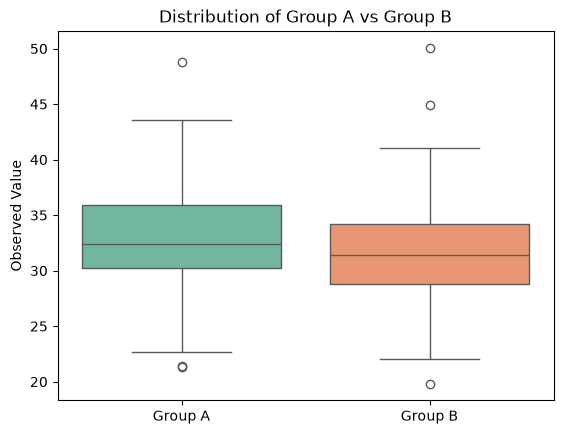

In [3]:
sns.boxplot(data=[a, b], palette="Set2")
plt.xticks(ticks=[0, 1], labels=["Group A", "Group B"])
plt.ylabel("Observed Value")
plt.title("Distribution of Group A vs Group B")

plt.show()

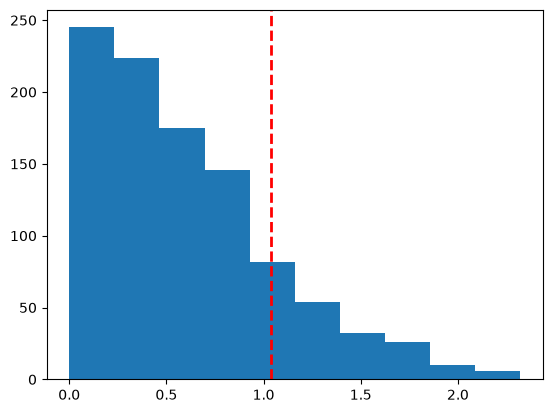

In [4]:
plot = plt.hist(permut_mean_diffs)
plt.axvline(
    x=mean_diffs, color="red", linestyle="--", linewidth=2, label="Observed Diff"
)

# Bootstrapping Permutation

In [5]:
a_size = 99
a_dist = ss.norm(loc=33, scale=5)
b_size = 83
b_dist = ss.norm(loc=32, scale=5)

a = a_dist.rvs(a_size)
b = b_dist.rvs(b_size)
print(a.var(), b.var())

n_reps = 10000
# combine all data from a and b
combined = np.hstack((a, b))
# selecting new a and b but with replacement
permuts = rng.permuted(np.tile(combined, reps=(n_reps, 1)), axis=1)
a_permuts = rng.choice(permuts[:, :a_size], n_reps, replace=True)
b_permuts = rng.choice(permuts[:, a_size:], n_reps, replace=True)
a_permut_means = a_permuts.mean(axis=1)
b_permut_means = b_permuts.mean(axis=1)
permut_mean_diffs = np.abs(a_permut_means - b_permut_means)
mean_diffs = np.abs(a.mean() - b.mean())
p = np.mean((permut_mean_diffs >= mean_diffs).astype(np.uint8))
p

19.94399841720129 22.64599170757499


np.float64(0.0019)

In [6]:
equal_var = ss.levene(a, b)
print(equal_var)
t, p = ss.ttest_ind(a, b, equal_var=False)
t, p

LeveneResult(statistic=np.float64(0.37669739506445765), pvalue=np.float64(0.5401509180534161))


(np.float64(2.292484864813773), np.float64(0.023102560328480994))

In [7]:
a_conv = 200
a_not_conv = 23539
a_len = a_conv + a_not_conv
b_conv = 182
b_not_conv = 2406
b_len = b_conv + b_not_conv
a_dist = ss.binom(n=a_len, p=a_conv / a_len)
b_dist = ss.binom(n=b_len, p=b_conv / b_len)
a = a_dist.rvs((10000, a_len))
b = b_dist.rvs((10000, b_len))
a.shape

(10000, 23739)

In [8]:
a = rng.normal(100, 15, size=999)
b = rng.normal(103, 16, size=999)
c = rng.normal(108, 12, size=999)
d = rng.normal(96, 11, size=999)
res_oneway = ss.f_oneway(a, b, c, d, equal_var=False)
res_twoway = ss.f_(a, b, c, d, equal_var=False)
res_oneway

AttributeError: module 'scipy.stats' has no attribute 'f_'

In [ ]:
a = rng.normal(100, 15, size=999)
b = rng.normal(103, 16, size=999)
# c = rng.normal(108, 12, size=999)
means = np.array([arr.mean() for arr in (a, b, c)])
b.var() / a.var(), ss.f_oneway(a, b)

(np.float64(1.164814180919453),
 F_onewayResult(statistic=np.float64(30.386993525059573), pvalue=np.float64(3.997912123587972e-08)))

In [11]:
import polars as pl
import polars.testing as plt

gender = np.array([1] * 95 + [0] * 105, dtype=np.uint8)
other = rng.choice(np.linspace(0, 4, dtype=np.uint8), size=len(gender))
gender.shape, other.shape

plot_df = pl.DataFrame({"gender": gender, "other": other})
count_df = (
    plot_df.group_by("other")
    .agg(pl.col("gender").value_counts())
    .explode("gender")
    .unnest("gender")
)
count_df2 = plot_df.with_columns(count=pl.len().over(["other", "gender"]))
print(count_df)
plt.assert_frame_equal(
    count_df, count_df2, check_column_order=False, check_row_order=False
)
# ss.chisquare(gender, other)
count_df.head()

shape: (9, 3)
┌───────┬────────┬───────┐
│ other ┆ gender ┆ count │
│ ---   ┆ ---    ┆ ---   │
│ u8    ┆ u8     ┆ u32   │
╞═══════╪════════╪═══════╡
│ 2     ┆ 1      ┆ 21    │
│ 2     ┆ 0      ┆ 29    │
│ 4     ┆ 1      ┆ 4     │
│ 0     ┆ 1      ┆ 22    │
│ 0     ┆ 0      ┆ 27    │
│ 3     ┆ 0      ┆ 26    │
│ 3     ┆ 1      ┆ 18    │
│ 1     ┆ 1      ┆ 30    │
│ 1     ┆ 0      ┆ 23    │
└───────┴────────┴───────┘


/var/folders/py/rttdn1tx393dt1bm4s3xzs_h0000gq/T/ipykernel_64791/1657299703.py:8: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  count_df = plot_df.group_by("other").agg(pl.col("gender").value_counts()).explode("gender").unnest("gender")


AssertionError: DataFrames are different (height (row count) mismatch)
[left]: 9
[right]: 200